# Social-Media-Only Models — Predicting Daily Change in Polymarket Trump Probability

Four regression models trained exclusively on Bluesky and Reddit social-media features:
1. **Ridge Regression** — regularised linear baseline; alpha tuned by CV  
   *(Plain OLS is underdetermined in early CV folds where n_train ≈ 26 < 61 features — Ridge prevents degenerate solutions.)*
2. **Random Forest** — tree ensemble; tuned `max_depth`, `min_samples_leaf`
3. **SVM** — kernel regression; tuned `kernel`, `C`, `epsilon`
4. **XGBoost** — gradient boosting; tuned `max_depth`, `learning_rate`, `n_estimators`

**Target:** `Δ polymarket_trump_prob = prob(t) − prob(t−1)` — daily change in Trump win probability  
**Features (61):** Bluesky volume, sentiment, NRC emotions + Reddit volume, engagement, sentiment, NRC emotions.

> **Note on contemporaneous features.** Most social-media features are same-day aggregates (e.g. `bsky_trump_unique_authors` for day *t*). They are not leaked in the pipeline sense — training scalers are fitted on train folds only, and the test set is never seen during selection. The two `_lag1` features (`bsky_sentiment_gap_lag1`, `reddit_sentiment_gap_lag1`) are strictly backward-looking.

**Hyperparameter tuning:** grid search using the same 3 walk-forward CV folds for RF, SVM, and XGBoost. Ridge alpha is tuned in the same way. The test set is completely untouched during tuning.

**Splits:** walk-forward expanding-window CV, 3 folds, gap = 1 day, held-out test = last 14 days  
**Metrics:** MAE, RMSE, Directional Accuracy, R²

## 1. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval, tune_hyperparams,
)
from house_style import (
    apply_style, BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED,
    SPINE_COLOR, GRID_COLOR, DEMOCRAT, REPUBLICAN, NEUTRAL, PALETTE,
)
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

SOCIAL_COLS = [
    # ── Bluesky volume & author diversity ─────────────────────────────────────────────
    "bsky_trump_unique_authors", "bsky_harris_unique_authors",
    "bsky_trump_share", "bsky_harris_share", "bsky_posts_per_author",
    # ── Bluesky sentiment ─────────────────────────────────────────────────────────────
    "bsky_harris_sent_avg", "bsky_harris_pos_share", "bsky_harris_neg_share",
    "bsky_election_sent_avg", "bsky_election_sent_std",
    "bsky_election_pos_share", "bsky_election_neg_share",
    "bsky_sentiment_gap", "bsky_sentiment_gap_lag1",
    # ── Bluesky NRC emotions ────────────────────────────────────────────────────────
    "bsky_trump_fear", "bsky_trump_trust", "bsky_trump_surprise",
    "bsky_trump_sadness", "bsky_trump_disgust", "bsky_trump_joy",
    "bsky_harris_fear", "bsky_harris_anger", "bsky_harris_anticipation",
    "bsky_harris_trust", "bsky_harris_disgust", "bsky_harris_joy",
    "bsky_election_surprise", "bsky_election_joy",
    # ── Reddit volume & engagement ──────────────────────────────────────────────────
    "reddit_unique_authors", "reddit_avg_score",
    "reddit_avg_upvote_ratio", "reddit_avg_comments",
    "reddit_harris_unique_authors", "reddit_harris_share",
    "reddit_conservative_share", "reddit_posts_per_author",
    # ── Reddit sentiment ─────────────────────────────────────────────────────────────
    "reddit_trump_sent_avg", "reddit_trump_sent_std",
    "reddit_harris_sent_std",
    "reddit_sentiment_gap", "reddit_sentiment_gap_lag1",
    # ── Reddit NRC emotions ──────────────────────────────────────────────────────────
    "reddit_trump_fear", "reddit_trump_anger", "reddit_trump_anticipation",
    "reddit_trump_trust", "reddit_trump_surprise", "reddit_trump_sadness",
    "reddit_trump_disgust", "reddit_trump_joy",
    "reddit_harris_anticipation", "reddit_harris_trust",
    "reddit_harris_sadness", "reddit_harris_disgust", "reddit_harris_joy",
    "reddit_election_fear", "reddit_election_anger", "reddit_election_anticipation",
    "reddit_election_surprise", "reddit_election_sadness", "reddit_election_joy",
    "reddit_election_sent_std",
]

MODEL_COLORS = {
    "Naive (zero)"   : NEUTRAL,
    "Ridge Regression": PALETTE[0],
    "Random Forest"  : PALETTE[1],
    "SVM"            : PALETTE[4],
    "XGBoost"        : PALETTE[2],
}

print("Imports OK")

Imports OK


## 2. Load Data & Compute Target

We load `basetable_preprocessed.csv` and keep only the 61 social-media columns.

**Target derivation:**  
`target(t) = polymarket_trump_prob(t) − polymarket_trump_prob_lag1(t) = prob(t) − prob(t−1)`

Using the pre-computed `polymarket_trump_prob_lag1` column (already in the preprocessed file) mirrors the approach in `1_lag.ipynb` and avoids any forward-looking `.diff()` ambiguity at dataset boundaries.

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

missing = [c for c in SOCIAL_COLS if c not in df_raw.columns]
assert not missing, f"Missing social-media columns: {missing} — re-run preprocessing.ipynb"
assert "polymarket_trump_prob_lag1" in df_raw.columns, \
    "polymarket_trump_prob_lag1 not found in preprocessed file — re-run preprocessing.ipynb"

df = df_raw[["date"] + SOCIAL_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]
df = df.dropna().reset_index(drop=True)  # removes any row where a social-media feature is NaN

print(f"Rows          : {len(df)}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features ({len(SOCIAL_COLS)}): {len(SOCIAL_COLS)} social-media columns")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows          : 123
Date range    : 2024-07-05 -> 2024-11-04
Features (61): 61 social-media columns

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 3. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** as a completely held-out test set. These dates are never seen during training or model selection — they are used only once for the final reported numbers.

The remaining rows form the **TV (train/validation) set**, split further into CV folds.

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[SOCIAL_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[SOCIAL_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 4. CV Folds

**3 expanding-window folds** on the TV set with a 1-day gap. `validate_no_leakage` asserts: no index overlap, all training dates strictly before validation dates, and the calendar gap ≥ 1 day.

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 5. Helper Functions

All helpers are imported from `Functions.evaluation_metrics`:
- **`directional_accuracy`** — fraction of correct sign predictions
- **`compute_metrics`** — MAE, RMSE, Directional Accuracy, R²
- **`cv_evaluate`** — walk-forward CV with scaler fitted on train fold only
- **`final_eval`** — retrain on full TV set, evaluate on held-out test set
- **`tune_hyperparams`** — grid search using walk-forward folds; returns best params and a sorted results DataFrame

## 6. Model 1 — Ridge Regression

Ridge adds an L2 penalty to OLS: `β̂ = argmin ‖y − Xβ‖² + α‖β‖²`. This shrinks coefficients toward zero, which is essential here because:
- The smallest CV training fold has ~26 rows vs 61 features (n < p) — plain OLS is underdetermined and would produce arbitrary solutions.
- Even where n > p, the design matrix is likely near-singular given correlated emotion/sentiment columns.

**Tuned hyperparameter:** `alpha` — regularisation strength; higher = stronger shrinkage.

**Scaling applied** — Ridge's margin is distance-based; unscaled features with different magnitudes distort the penalty.

In [5]:
def make_ridge(alpha):
    return Ridge(alpha=alpha)

ridge_param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

print("=== Ridge Regression — Hyperparameter Tuning ===")
ridge_best, ridge_tune_df = tune_hyperparams(
    make_ridge, ridge_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {ridge_best}")
print(f"\n  All configurations (sorted by CV MAE):")
print(ridge_tune_df.to_string(index=False))

ridge_factory = lambda: make_ridge(**ridge_best)
print("\n=== Ridge Regression — CV (best params) ===")
ridge_cv = cv_evaluate(ridge_factory, folds, X_tv, y_tv, scale=True)
ridge_cv.round(4)

=== Ridge Regression — Hyperparameter Tuning ===
  Best params : {'alpha': 1000.0}

  All configurations (sorted by CV MAE):
  alpha   cv_mae  cv_mae_std
1000.00 0.010300    0.001763
 500.00 0.010370    0.001651
 100.00 0.011330    0.000979
  10.00 0.020475    0.003626
   1.00 0.034379    0.003575
   0.10 0.042618    0.009252
   0.01 0.045017    0.012127

=== Ridge Regression — CV (best params) ===
  Fold 1: MAE=0.0115  RMSE=0.0151  DA=0.556  R2=-0.0033
  Fold 2: MAE=0.0078  RMSE=0.0101  DA=0.444  R2=-0.0446
  Fold 3: MAE=0.0116  RMSE=0.0159  DA=0.296  R2=-0.2468
  -- Mean --  MAE=0.0103  RMSE=0.0137  DA=0.432  R2=-0.0982


,MAE,RMSE,Dir. Accuracy,R2
1,0.0115,0.0151,0.5556,-0.0033
2,0.0078,0.0101,0.4444,-0.0446
3,0.0116,0.0159,0.2963,-0.2468
Mean,0.0103,0.0137,0.4321,-0.0982
Std,0.0022,0.0032,0.1301,0.1303


In [6]:
ridge_model, ridge_pred, ridge_test = final_eval(
    ridge_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print(f"Ridge Regression — Test set  (alpha={ridge_best['alpha']}):")
for k, v in ridge_test.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression — Test set  (alpha=1000.0):
  MAE: 0.0158
  RMSE: 0.0211
  Dir. Accuracy: 0.5000
  R2: -0.0880


## 7. Model 2 — Random Forest Regressor

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample with a random feature subset at each split. With 61 features, RF naturally performs implicit feature selection at each split, making it well-suited to high-dimensional social-media data.

**Fixed:** `n_estimators=200`, `random_state=42`.  
**Tuned:** `max_depth`, `min_samples_leaf`.  
**No scaling required** — tree splits are threshold-based and scale-invariant.

In [7]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'min_samples_leaf': 2}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 2 0.010542    0.001515
         3                 2 0.010572    0.001588
         4                 2 0.010615    0.001576
         2                 3 0.010640    0.001809
         5                 5 0.010652    0.001520

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0116  RMSE=0.0152  DA=0.444  R2=-0.0144
  Fold 2: MAE=0.0084  RMSE=0.0106  DA=0.519  R2=-0.1495
  Fold 3: MAE=0.0116  RMSE=0.0157  DA=0.481  R2=-0.2070
  -- Mean --  MAE=0.0105  RMSE=0.0138  DA=0.481  R2=-0.1236


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0152,0.4444,-0.0144
2,0.0084,0.0106,0.5185,-0.1495
3,0.0116,0.0157,0.4815,-0.2070
Mean,0.0105,0.0138,0.4815,-0.1236
Std,0.0019,0.0028,0.0370,0.0988


Random Forest — Test set:
  MAE: 0.0159
  RMSE: 0.0210
  Dir. Accuracy: 0.5000
  R2: -0.0825


C:\Users\ninav\AppData\Local\Temp\ipykernel_13628\1390898195.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(top_fi.index, color=TEXT_PRIMARY, fontsize=8)


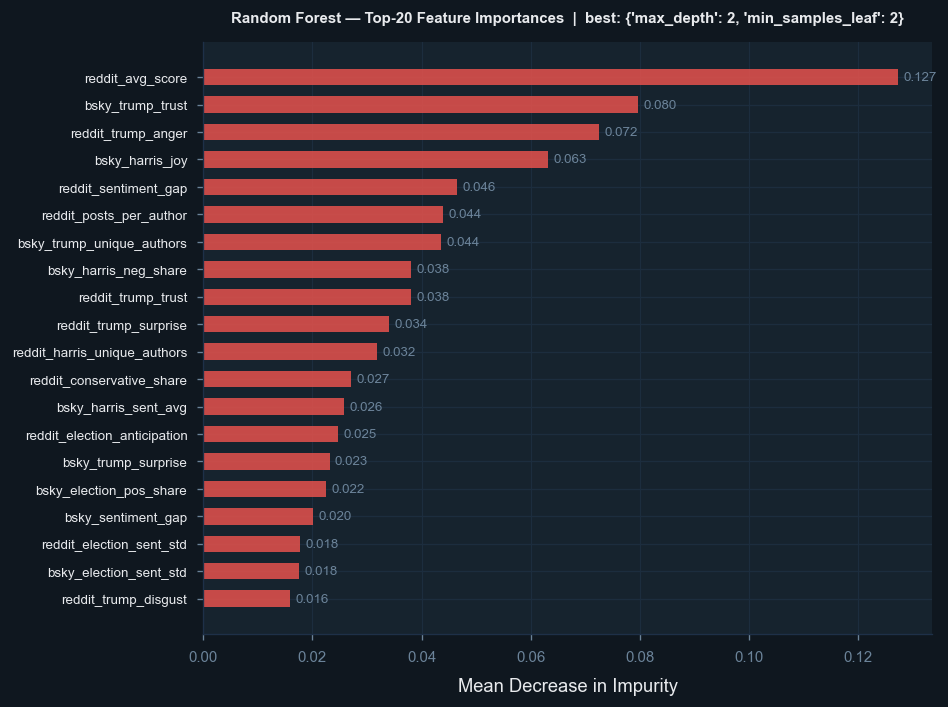

In [8]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=SOCIAL_COLS).sort_values(ascending=True)
top_fi = fi.tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(top_fi.index, top_fi.values, color=MODEL_COLORS["Random Forest"], alpha=0.85, height=0.6)
for bar, v in zip(bars, top_fi.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=8, color=TEXT_MUTED)
ax.set_xlabel("Mean Decrease in Impurity", color=TEXT_PRIMARY)
ax.set_title(f"Random Forest — Top-20 Feature Importances  |  best: {rf_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(top_fi.index, color=TEXT_PRIMARY, fontsize=8)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 8. Model 3 — Support Vector Regression (tuned kernel)

SVR finds a regression function within an epsilon-tube; the kernel implicitly maps features into a higher-dimensional space. With 61 features, the linear kernel effectively performs L2-penalised regression, while RBF/poly capture non-linear interactions.

**Fixed:** `gamma='scale'`.  
**Tuned:** `kernel`, `C`, `epsilon`.  
**Scaling required** — SVR's geometric margin is distorted by unscaled features.

In [9]:
def make_svr(kernel, C, epsilon):
    return SVR(kernel=kernel, C=C, epsilon=epsilon, gamma="scale")

svr_param_grid = {
    "kernel" : ["linear", "rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-10 configurations (sorted by CV MAE):")
print(svr_tune_df.head(10).to_string(index=False))

svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM — Hyperparameter Tuning ===
  Best params : {'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.01}

  Top-10 configurations (sorted by CV MAE):
kernel     C  epsilon   cv_mae  cv_mae_std
   rbf  10.0   0.0100 0.010635    0.001840
   rbf 100.0   0.0100 0.010635    0.001840
   rbf   1.0   0.0100 0.010635    0.001840
   rbf   0.1   0.0100 0.010636    0.001835
   rbf   0.1   0.0010 0.010825    0.001626
   rbf   0.1   0.0001 0.010865    0.001604
   rbf 100.0   0.0010 0.010959    0.001685
   rbf   1.0   0.0010 0.010959    0.001685
   rbf  10.0   0.0010 0.010959    0.001685
   rbf  10.0   0.0001 0.011000    0.001679

=== SVM — CV (best params) ===
  Fold 1: MAE=0.0124  RMSE=0.0159  DA=0.481  R2=-0.1121
  Fold 2: MAE=0.0081  RMSE=0.0101  DA=0.481  R2=-0.0525
  Fold 3: MAE=0.0114  RMSE=0.0161  DA=0.481  R2=-0.2704
  -- Mean --  MAE=0.0106  RMSE=0.0140  DA=0.481  R2=-0.1450


,MAE,RMSE,Dir. Accuracy,R2
1,0.0124,0.0159,0.4815,-0.1121
2,0.0081,0.0101,0.4815,-0.0525
3,0.0114,0.0161,0.4815,-0.2704
Mean,0.0106,0.0140,0.4815,-0.1450
Std,0.0023,0.0034,0.0000,0.1126


In [10]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print(f"SVM — Test set  (kernel={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}):")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM — Test set  (kernel=rbf, C=1.0, ε=0.01):
  MAE: 0.0166
  RMSE: 0.0227
  Dir. Accuracy: 0.5000
  R2: -0.2609


## 9. Model 4 — XGBoost Regressor

XGBoost builds trees sequentially, each fitting the pseudo-residuals of the current ensemble. The implicit feature selection at each split handles the 61-feature space well; `colsample_bytree=0.8` further reduces variance by using a random 80 % of features per tree.

**Fixed:** `subsample=0.8`, `colsample_bytree=0.8`, `objective='reg:squarederror'`, `random_state=42`.  
**Tuned:** `max_depth`, `learning_rate`, `n_estimators`.  
**No scaling required** — tree splits are scale-invariant.

In [11]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         3           0.01           100 0.010521    0.001927
         4           0.01           100 0.010598    0.001940
         3           0.01           200 0.010612    0.001921
         2           0.01           100 0.010614    0.002000
         4           0.01           200 0.010780    0.001833

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0120  RMSE=0.0155  DA=0.481  R2=-0.0533
  Fold 2: MAE=0.0078  RMSE=0.0098  DA=0.593  R2=0.0146
  Fold 3: MAE=0.0118  RMSE=0.0161  DA=0.370  R2=-0.2733
  -- Mean --  MAE=0.0105  RMSE=0.0138  DA=0.481  R2=-0.1040


,MAE,RMSE,Dir. Accuracy,R2
1,0.0120,0.0155,0.4815,-0.0533
2,0.0078,0.0098,0.5926,0.0146
3,0.0118,0.0161,0.3704,-0.2733
Mean,0.0105,0.0138,0.4815,-0.1040
Std,0.0024,0.0035,0.1111,0.1505


XGBoost — Test set:
  MAE: 0.0161
  RMSE: 0.0212
  Dir. Accuracy: 0.5714
  R2: -0.0994


C:\Users\ninav\AppData\Local\Temp\ipykernel_13628\3733470784.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(top_xgb.index, color=TEXT_PRIMARY, fontsize=8)


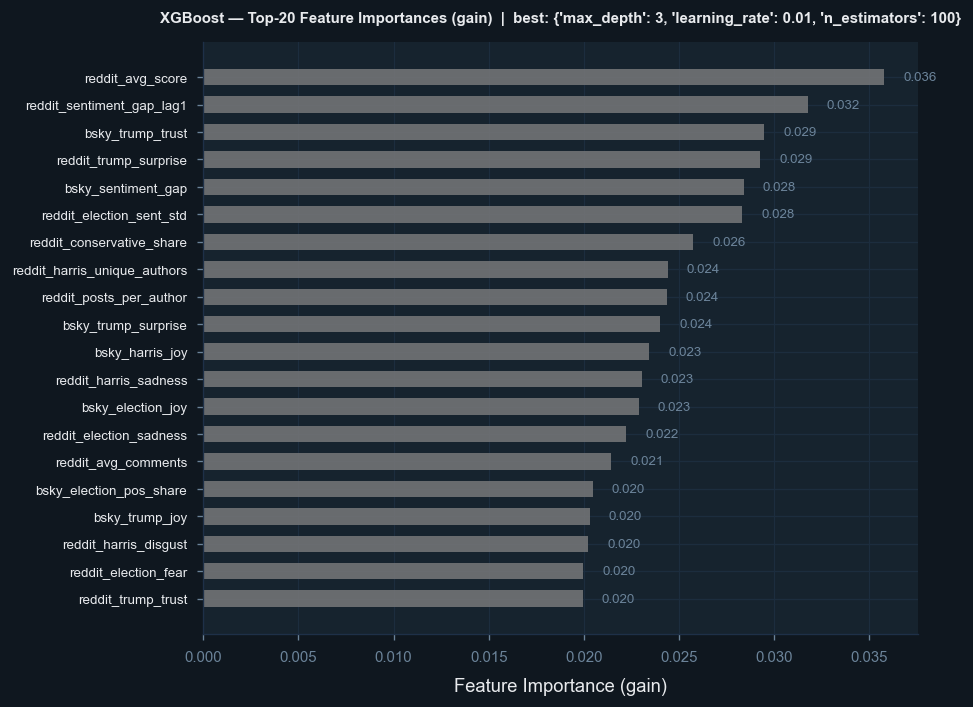

In [12]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

fi_xgb = pd.Series(xgb_model.feature_importances_, index=SOCIAL_COLS).sort_values(ascending=True)
top_xgb = fi_xgb.tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(top_xgb.index, top_xgb.values, color=MODEL_COLORS["XGBoost"], alpha=0.85, height=0.6)
for bar, v in zip(bars, top_xgb.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=8, color=TEXT_MUTED)
ax.set_xlabel("Feature Importance (gain)", color=TEXT_PRIMARY)
ax.set_title(f"XGBoost — Top-20 Feature Importances (gain)  |  best: {xgb_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(top_xgb.index, color=TEXT_PRIMARY, fontsize=8)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 10. Naive Baseline — Always Predict Zero

The naive model always predicts `Δ prob = 0` (no change). This is the random-walk lower bound: R² ≈ 0 for the zero predictor when the mean daily change is near zero. Any model with R² < 0 is strictly worse than predicting no movement.

**Note on Directional Accuracy:** `sign(0) = 0`, so the naive model scores a correct direction only on days where the actual change is also exactly zero — near 0 for a continuous series.

In [13]:
print("=== Naive (zero) — CV ===")
naive_records = []
for i, (train_idx, val_idx) in enumerate(folds, 1):
    y_val  = y_tv[val_idx]
    y_zero = np.zeros_like(y_val)
    m = {"Fold": i, **compute_metrics(y_val, y_zero)}
    naive_records.append(m)
    print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

naive_agg  = pd.DataFrame(naive_records).set_index("Fold")
naive_mean = naive_agg.mean().rename("Mean")
naive_std  = naive_agg.std().rename("Std")
naive_cv   = pd.concat([naive_agg, naive_mean.to_frame().T, naive_std.to_frame().T])
print(f"  -- Mean --  MAE={naive_mean['MAE']:.4f}  RMSE={naive_mean['RMSE']:.4f}  "
      f"DA={naive_mean['Dir. Accuracy']:.3f}  R2={naive_mean['R2']:.4f}")

naive_pred = np.zeros(len(y_test))
naive_test = compute_metrics(y_test, naive_pred)
print("\nNaive (zero) — Test set:")
for k, v in naive_test.items():
    print(f"  {k}: {v:.4f}")

naive_cv.round(4)

=== Naive (zero) — CV ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.000  R2=-0.0044
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.037  R2=-0.0013
  Fold 3: MAE=0.0111  RMSE=0.0155  DA=0.000  R2=-0.1700
  -- Mean --  MAE=0.0101  RMSE=0.0135  DA=0.012  R2=-0.0586

Naive (zero) — Test set:
  MAE: 0.0162
  RMSE: 0.0208
  Dir. Accuracy: 0.0000
  R2: -0.0570


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.0000,-0.0044
2,0.0076,0.0099,0.0370,-0.0013
3,0.0111,0.0155,0.0000,-0.1700
Mean,0.0101,0.0135,0.0123,-0.0586
Std,0.0022,0.0031,0.0214,0.0965


## 11. Model Comparison

CV performance (mean over 3 folds) and test-set performance for all five models. The naive (zero) baseline sets the floor: a model must beat it on MAE/RMSE to be worth using.

**Metrics:** MAE, RMSE, Directional Accuracy (0.5 = coin flip), R² (0 = naive, negative = worse than naive).

In [14]:
cv_summary = pd.DataFrame({
    "Naive (zero)"   : naive_cv.loc["Mean"],
    "Ridge Regression": ridge_cv.loc["Mean"],
    "Random Forest"  : rf_cv.loc["Mean"],
    "SVM"            : svm_cv.loc["Mean"],
    "XGBoost"        : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Naive (zero)"   : "— (always 0)",
    "Ridge Regression": f"alpha={ridge_best['alpha']}",
    "Random Forest"  : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM"            : f"k={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"        : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

CV performance (mean across 3 walk-forward folds):


,Best params,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),— (always 0),0.0101,0.0135,0.0123,-0.0586
Ridge Regression,alpha=1000.0,0.0103,0.0137,0.4321,-0.0982
Random Forest,"d=2, leaf=2",0.0105,0.0138,0.4815,-0.1236
SVM,"k=rbf, C=1.0, ε=0.01",0.0106,0.0140,0.4815,-0.1450
XGBoost,"d=3, lr=0.01, n=100",0.0105,0.0138,0.4815,-0.1040


In [15]:
test_summary = pd.DataFrame({
    "Naive (zero)"   : naive_test,
    "Ridge Regression": ridge_test,
    "Random Forest"  : rf_test,
    "SVM"            : svm_test,
    "XGBoost"        : xgb_test,
}).T.round(4)

print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),0.0162,0.0208,0.0000,-0.0570
Ridge Regression,0.0158,0.0211,0.5000,-0.0880
Random Forest,0.0159,0.0210,0.5000,-0.0825
SVM,0.0166,0.0227,0.5000,-0.2609
XGBoost,0.0161,0.0212,0.5714,-0.0994


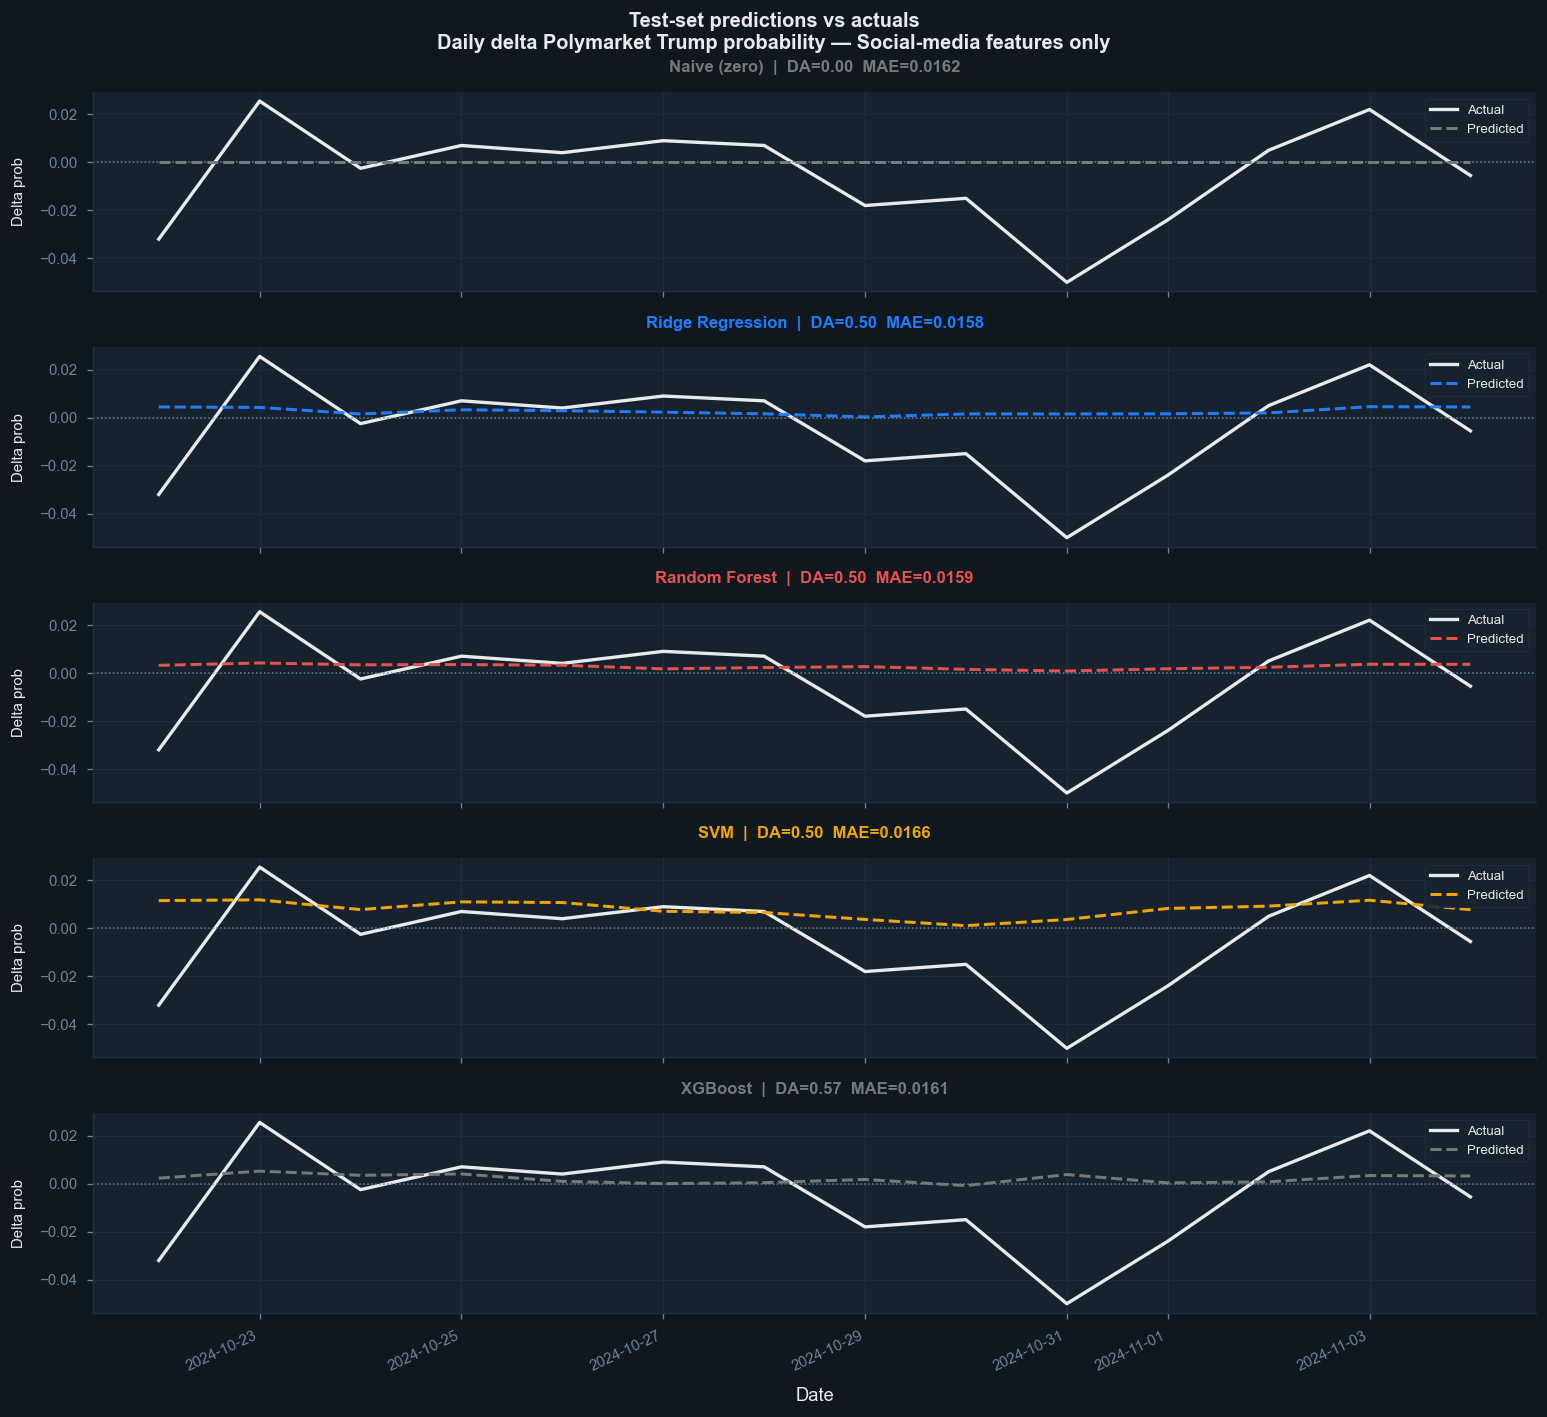

In [16]:
test_dates = df_test["date"].values
preds_list = [
    ("Naive (zero)",    naive_pred),
    ("Ridge Regression", ridge_pred),
    ("Random Forest",   rf_pred),
    ("SVM",             svm_pred),
    ("XGBoost",         xgb_pred),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — Social-media features only",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

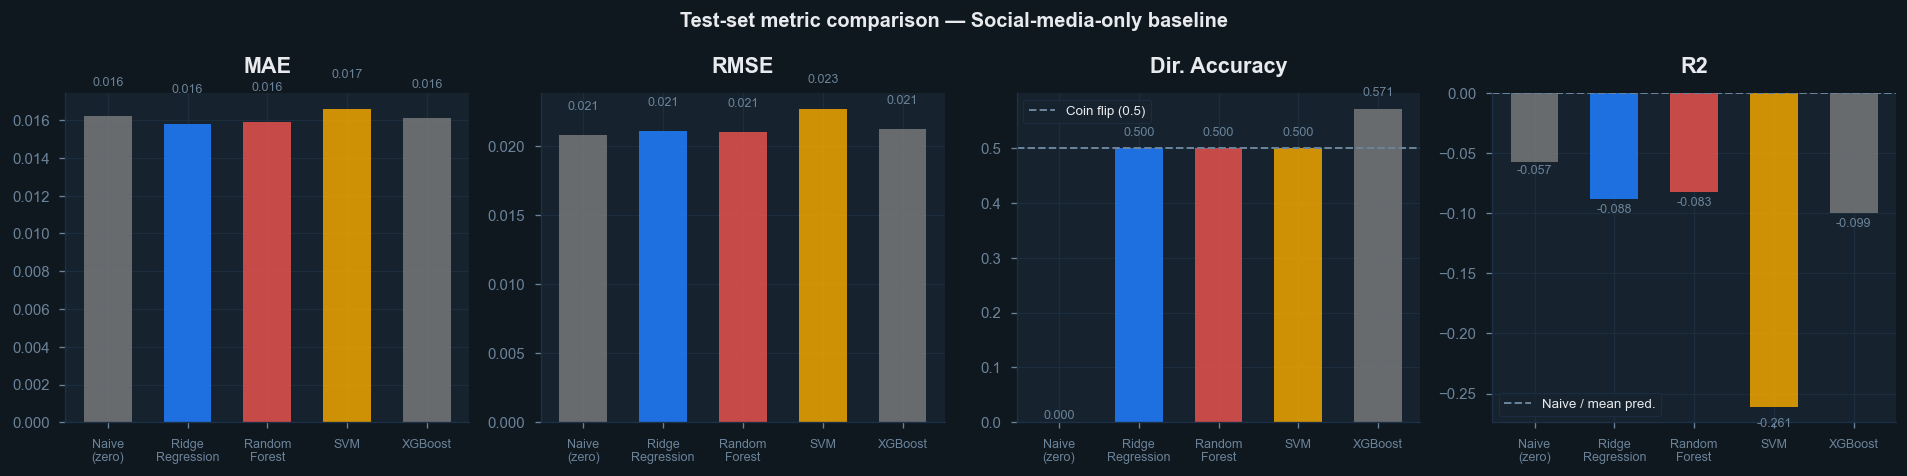

In [17]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Coin flip (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Naive / mean pred.")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=7.5, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=7.5, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Social-media-only baseline",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path

# ── Export test-set results to CSV for model_analysis.ipynb ──────────────────
FEATURE_SET = "Social (61f)"
CSV_NAME    = "social_61f.csv"
OUT_DIR     = Path("../../4_model_analysis/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_export = test_summary.copy()
df_export.index.name = "Model"
df_export = df_export.reset_index()
df_export = df_export.rename(columns={"Dir. Accuracy": "DA"})
df_export["Model"] = df_export["Model"].replace({"Ridge Regression": "Ridge"})
df_export.insert(0, "Feature_set", FEATURE_SET)

out_path = OUT_DIR / CSV_NAME
df_export.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
display(df_export)

Results saved → ..\..\4_model_analysis\results\social_61f.csv


,Feature_set,Model,MAE,RMSE,DA,R2
0,Social (61f),Naive (zero),0.0162,0.0208,0.0000,-0.0570
1,Social (61f),Ridge,0.0158,0.0211,0.5000,-0.0880
2,Social (61f),Random Forest,0.0159,0.0210,0.5000,-0.0825
3,Social (61f),SVM,0.0166,0.0227,0.5000,-0.2609
4,Social (61f),XGBoost,0.0161,0.0212,0.5714,-0.0994
